### Домашняя работа

**Задание среднего уровня** Примените градиентный спуск к задаче прогнозирования цен на недвижимость в Бостоне. Какого качества на валидации удалось достичь по r2-score? Сколько итераций  понадобилось?

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
#загрузка данных
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
raw_df

,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8
...,...,...,...,...,...,...,...,...,...,...,...
1007,396.90000,5.64,23.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1008,0.10959,0.00,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0
1009,393.45000,6.48,22.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1010,0.04741,0.00,11.93,0.0,0.573,6.030,80.8,2.5050,1.0,273.0,21.0


In [82]:
#создание матрицы признаков и целевой переменной 
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]]) #объединяем признаки
target = raw_df.values[1::2, 2] #извлекаем целевую переменную
#разделение на обучающую и тестовую выборки
#20% данных пойдут в валидационную выборку
#для воспроизводимости результатов используем функцию train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

In [83]:
#выясняем количество признаков для обучения
X_train.shape, 
X_test.shape


(102, 13)

In [84]:
y_train.shape,
y_test.shape

(102,)

In [85]:
# для регрессии
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from scipy.spatial import distance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

Шаг 0: weight_change = 4.939370, MSE = 128.598833
Шаг 100: weight_change = 0.000870, MSE = 24.394417
Итарации остановлены на шаге 142


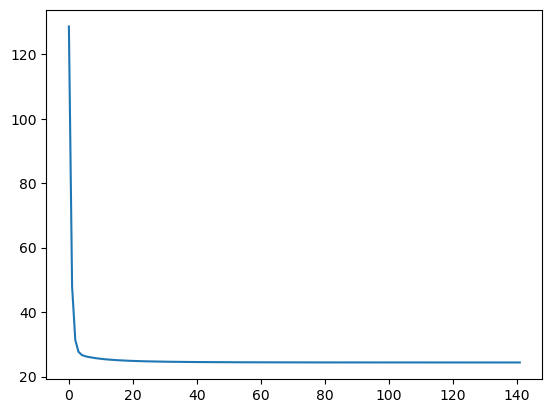

In [135]:

#сначала стандартизируем данные вручную
scaler = StandardScaler()
X_train = scaler.fit_transform(np.array(X_train))
X_test = scaler.transform(np.array(X_test))

#создаем экземпляр SGD регрессор
sgd = SGDRegressor(learning_rate='constant', eta0=0.002, random_state=42, fit_intercept = True)

w_current, epsilon = np.random.random(X_train.shape[1]), 0.0001
weight_evolution, mse_evolution = [], []

for step in list(range(2000)):
    
    #вызываем partial_fit на созданном экземпляре sgd
    sgd.partial_fit(X_train, y_train)
    
    #проверяем изменение весов
    weight_evolution.append(distance.euclidean(w_current, sgd.coef_))
    weight_change = np.linalg.norm(w_current - sgd.coef_)
    
    #вычисляем MSE на тестовой выборке
    y_pred = sgd.predict(X_test)
    current_mse = mean_squared_error(y_test, y_pred)
    
    if step % 100 ==0:
        print(f"Шаг {step}: weight_change = {weight_change:.6f}, MSE = {current_mse:.6f}")
    if weight_evolution[-1] < epsilon:
        print("Итарации остановлены на шаге %d" % step); break


    mse_evolution.append(current_mse)
    #обновляем текущие веса
    w_current = sgd.coef_.copy()
plt.plot(range(step), mse_evolution)

In [ ]:
#Найден оптимальный параметр eta0 от 0.002 до 0.003 на уровне MSE = 24, модель обучается за 100 - 142 шага

Вы можете начать использовать градиентный спуск уже сейчас! Если вы хотите глубже понять механизмы, которые использует этот приём - добро пожаловать в урок 5, где мы поговорим о математике, которая стоит за градиентным спуском и даже реализуем градиентный спуск на языке Python.